# Pop-Patch Correctness — Synthetic Edge-Case Demo

ArcticInference SuffixTree 의 `pop()` API 와 `temporary_extension`
context manager 가 **올바르게 구현되었음** 을 보이고, 패치의 긍정적 효과가
직접적으로 보이는 합성 edge case 를 제공한다.

## 검증 목록
1. **Pop bit-exact**: `extend → pop` 후 트리 상태가 정확히 복원.
2. **Both trees update**: `extend_active_response` 가 local + global 모두 업데이트.
3. **Context manager**: `temporary_extension` scope 가 정확히 진입/종료.
4. **Edge case (POSITIVE)**: 합성 데이터에서 patch 가 graft 에 도움되는 토큰 주입
   → mini greedy walk 에서 MAT 증가 직접 관찰.
5. **Counter-edge (NEGATIVE)**: 같은 setup 에서 GT 가 base 분포 따라가면 negative.
6. **Score dilution 수치 확인**: predicted ratio 와 empirical ratio 일치.

## 데이터 출처
이 노트북은 **호스트 머신** 에서 실행되며, `arctic_inference` 가 없으므로
**precomputed JSON 결과** 를 로드. 결과는 컨테이너 (`sglang-bench`) 에서
`tmp/precompute_correctness.py` 가 생성한 것. 위치:
`simulation/results/explorations/pop_patch_3wl/notebook1_results.json`.

In [43]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Try host path then container path then relative.
_CANDIDATES = [
    Path("/home/muchwater/advance-spec/simulation/results/explorations/pop_patch_3wl"),
    Path("/workspace/simulation/results/explorations/pop_patch_3wl"),
    Path.cwd().parent / "results" / "explorations" / "pop_patch_3wl",
]
DATA_DIR = next(p for p in _CANDIDATES if p.exists())
RESULTS_PATH = DATA_DIR / "notebook1_results.json"

with open(RESULTS_PATH) as f:
    R = json.load(f)
print(f"DATA_DIR = {DATA_DIR}")
print(f"Loaded sections: {list(R.keys())}")


DATA_DIR = /home/muchwater/advance-spec/simulation/results/explorations/pop_patch_3wl
Loaded sections: ['section_1_bit_exact', 'section_2_both_trees', 'section_3_context_manager', 'section_4_positive_edge', 'section_5_counter_edge', 'section_6_dilution']


## 1. Pop bit-exact 검증

`pop(seq, n)` 이 마지막 n 개의 `append` 를 정확히 reverse 하는지 확인.

### 시나리오
```
tree = SuffixTree(8, enable_undo=True)
tree.extend(0, [1, 2, 3])     # State A
tree.pop(0, 1)                 # State B (token 3 reversed)
tree.extend(0, [3])            # State C (re-add token 3)
```
각 시점에 `speculate([1, 2])` 의 결과 비교.

After extend [1,2,3]:  speculate([1,2]) → toks=[3]  score=1.0
After pop(0, 1):        speculate([1,2]) → toks=[]  score=0.0
After re-extend [3]:    speculate([1,2]) → toks=[3]  score=1.0

Bit-exact match (extend == re-extend): True
check_integrity OK: True

✓ Pop is bit-exact: extend → pop → re-extend yields identical tree state.


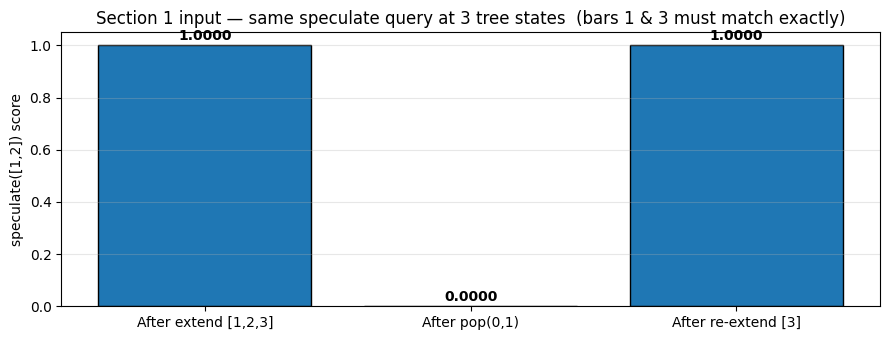

In [44]:
s = R["section_1_bit_exact"]
print(f"After extend [1,2,3]:  speculate([1,2]) → toks={s['after_extend']['tokens']}  score={s['after_extend']['score']}")
print(f"After pop(0, 1):        speculate([1,2]) → toks={s['after_pop']['tokens']}  score={s['after_pop']['score']}")
print(f"After re-extend [3]:    speculate([1,2]) → toks={s['after_reextend']['tokens']}  score={s['after_reextend']['score']}")
print()
print(f"Bit-exact match (extend == re-extend): {s['bit_exact_match']}")
print(f"check_integrity OK: {s['integrity_ok']}")
print()
print("✓ Pop is bit-exact: extend → pop → re-extend yields identical tree state.")

# Chart: speculate scores at 3 timepoints (visualize bit-exact restore)
fig, ax = plt.subplots(figsize=(9, 3.5))
labels = ["After extend [1,2,3]", "After pop(0,1)", "After re-extend [3]"]
scores = [s["after_extend"]["score"], s["after_pop"]["score"], s["after_reextend"]["score"]]
colors = ["#1f77b4", "#888888", "#1f77b4"]
bars = ax.bar(labels, scores, color=colors, edgecolor="black")
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + max(scores)*0.02,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("speculate([1,2]) score")
ax.set_title("Section 1 input — same speculate query at 3 tree states  (bars 1 & 3 must match exactly)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 2. 양쪽 트리 (local + global) 업데이트 확인

`SuffixDecodingCache.extend_active_response` 가 local seq=0 트리와
global allocated seq 트리 둘 다에 토큰을 추가하는지 검증.

                                         label  local  global pending
         After start_request prompt=[10,20,30]      3       0      []
 After add_active_response (PERMANENT) [40,50]      5       2      []
After extend_active_response (TEMP) [60,70,80]      8       5     [3]
              After pop_active_response (auto)      5       2      []

local check_integrity:  ''
global check_integrity: ''

✓ Both trees update symmetrically (+3 each on extend, -3 each on pop).


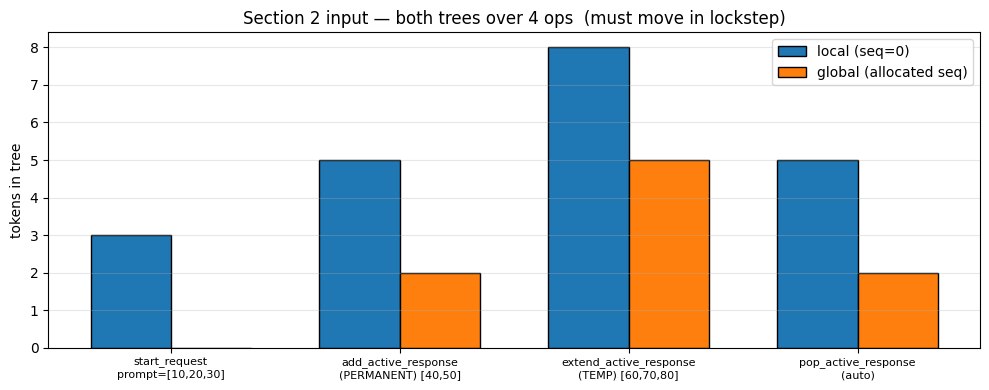

In [45]:
s = R["section_2_both_trees"]
df = pd.DataFrame(s["timeline"])
print(df.to_string(index=False))
print()
print(f"local check_integrity:  {repr(s['local_integrity'])}")
print(f"global check_integrity: {repr(s['global_integrity'])}")
print()
print("✓ Both trees update symmetrically (+3 each on extend, -3 each on pop).")

# Chart: local vs global tree size over operations
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(df))
width = 0.35
ax.bar(x - width/2, df["local"], width, label="local (seq=0)",
       color="#1f77b4", edgecolor="black")
ax.bar(x + width/2, df["global"], width, label="global (allocated seq)",
       color="#ff7f0e", edgecolor="black")
ax.set_xticks(x)
short_labels = [lbl.replace("After ", "").replace(" ", "\n", 1) for lbl in df["label"]]
ax.set_xticklabels(short_labels, fontsize=8)
ax.set_ylabel("tokens in tree")
ax.set_title("Section 2 input — both trees over 4 ops  (must move in lockstep)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 3. `temporary_extension` 컨텍스트 매니저

Scope 안에서 speculate 가 새 토큰을 매치하고, scope 종료 후 정확히 복원.

BEFORE temp:  toks=[] score=0.000
INSIDE temp:  toks=[99, 100] score=2.000
              ('99' 가 trie 에 들어가서 50 다음에 99가 매치됨)
AFTER  temp:  toks=[] score=0.000

BEFORE == AFTER (bit-exact restore): True
INSIDE differs from BEFORE (temp observable): True

✓ temp_extension actually inserts; scope exit restores bit-exactly.


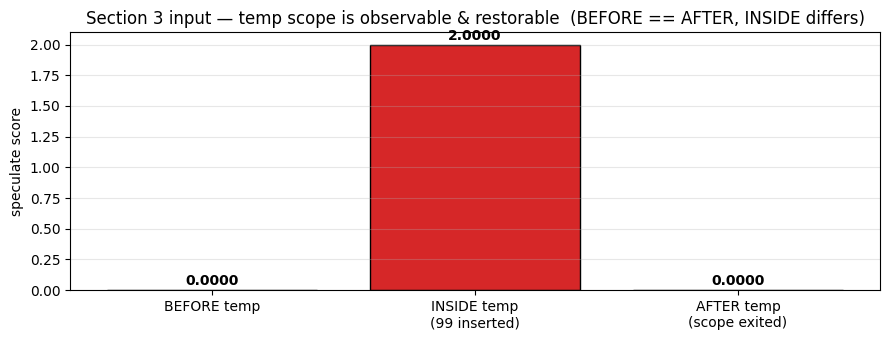

In [46]:
s = R["section_3_context_manager"]
ctx = "[10, 20, 30, 40, 50]"
print(f"BEFORE temp:  toks={s['before_temp']['tokens']} score={s['before_temp']['score']:.3f}")
print(f"INSIDE temp:  toks={s['inside_temp']['tokens']} score={s['inside_temp']['score']:.3f}")
print(f"              ('99' 가 trie 에 들어가서 50 다음에 99가 매치됨)")
print(f"AFTER  temp:  toks={s['after_temp']['tokens']} score={s['after_temp']['score']:.3f}")
print()
print(f"BEFORE == AFTER (bit-exact restore): {s['bit_exact_match']}")
print(f"INSIDE differs from BEFORE (temp observable): {s['inside_differs']}")
print()
print("✓ temp_extension actually inserts; scope exit restores bit-exactly.")

# Chart: speculate score at 3 phases (BEFORE, INSIDE, AFTER) — must be BEFORE==AFTER, INSIDE different
fig, ax = plt.subplots(figsize=(9, 3.5))
phases = ["BEFORE temp", "INSIDE temp\n(99 inserted)", "AFTER temp\n(scope exited)"]
scores = [s["before_temp"]["score"], s["inside_temp"]["score"], s["after_temp"]["score"]]
colors = ["#1f77b4", "#d62728", "#1f77b4"]
bars = ax.bar(phases, scores, color=colors, edgecolor="black")
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + max(scores)*0.02,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("speculate score")
ax.set_title("Section 3 input — temp scope is observable & restorable  (BEFORE == AFTER, INSIDE differs)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 4. Extension method 의 핵심: backbone 위 graft 가 어떻게 더 정확해지는가

### Extension 동작 (한 줄 요약)
> **각 backbone 노드 직전에 root→그 노드 까지의 path 를 suffix cache 에 임시로 넣어두고**
> graft(추가 suffix 예측) 를 계산한 뒤 곧바로 빼낸다 (`temporary_extension`).

### 왜 임시 주입이 도움이 되나
Suffix cache 의 `speculate` 는 **"context 의 가장 긴 suffix 가 cache 메모리에 있는 위치"** 를 찾고 그 뒤에 이어지는 토큰들을 예측 — 즉 **긴 match 일수록 길고 자신감 있는 prediction**.

- **패치 OFF**: cache 에 backbone path 가 없음 → context 끝부분 매치 안 됨 → 매치 짧음 → graft 짧음
- **패치 ON**: backbone path 가 cache 에 임시 등록됨 → context 전체와 긴 매치 → cache 가 이어지는 cyclic 구조를 학습해서 자신 있게 graft

### 합성 시나리오 — 음악 수업

이미 생성된 committed 출력 (base):

> *"I love to play music and **sing**"*

EAGLE3 backbone path 예측 — 음계가 두 번 반복되는 cyclic 구조:

> *do re mi fa sol la ti do'  **sing**  do re mi fa sol la ti do'  **sing***

이 backbone 의 마지막 노드 (마지막 **sing**) 에서 extension 이 graft 를 만든다. **GT (실제 모델이 출력할 다음 토큰들)** 는 또 한 번의 음계:

> *do re mi fa sol la ti do'*

전체 텍스트로 읽으면:

> *"I love to play music and **sing** do re mi fa sol la ti do' **sing** do re mi fa sol la ti do' **sing**"*

`sing` 이 음계 phrase 사이의 자연스러운 cycle marker.

### 두 cycle 이 필요한 이유
backbone 에 "sing → do re mi ... do'" 패턴이 **두 번** 나오면 suffix cache 의 transition count = 2 → 기본 `max_spec_factor=4.0` 하에서도 graft 가 8 토큰 깊이로 확장됨. 1 cycle 만으로는 count=1 → graft 가 얕음.

### 기대 결과
- **패치 OFF**: cache 에 음계 패턴이 등록 안 되어 graft 비어 있음 → GT 와 0 토큰 매치
- **패치 ON**: cache 가 패턴 학습 → graft 가 8 토큰 전체 예측 → GT 와 8 토큰 매치 → 한 step 에 8 토큰 추가 verify

EXTENSION METHOD — committed → backbone → graft 구조
committed  (회색)  : "I love to play music and sing"
backbone   (주황)  : "do re mi fa sol la ti do' sing do re mi fa sol la ti do' sing"
            ⤷ EAGLE3 가 예측한 cyclic refrain x 2
graft (extension)  : backbone leaf 위에 매달리는 추가 예측 (빨강)

Patch OFF — graft = ∅ (empty)
Patch ON  — graft = ['do', 're', 'mi', 'fa', 'sol', 'la', 'ti', "do'", 'sing']

GT (real next 8 tokens): "do re mi fa sol la ti do'"
  → Patch ON 의 graft 첫 8 토큰이 GT 와 정확히 일치  → +8 토큰 추가 verify


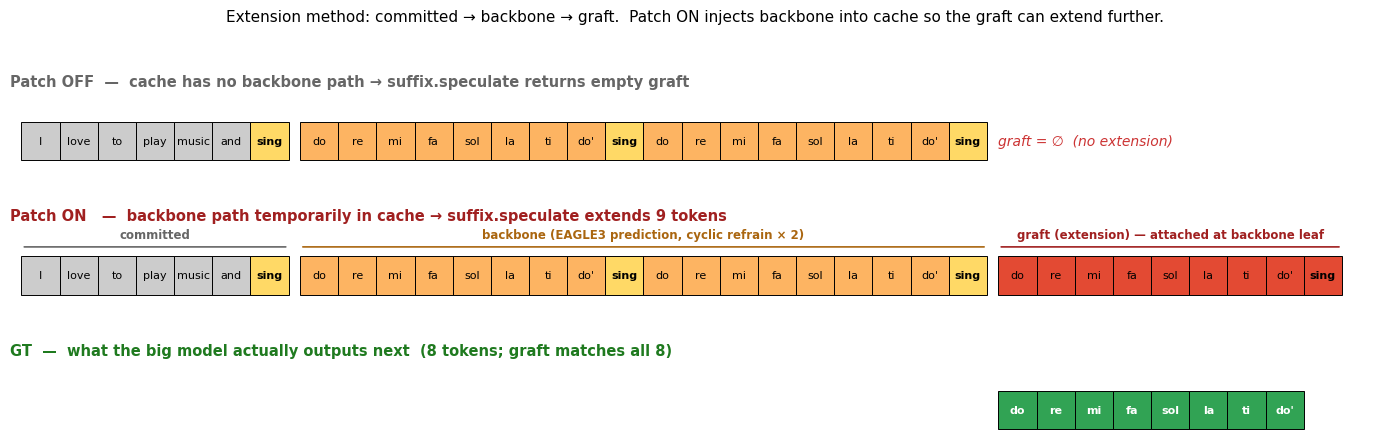

In [47]:
s = R["section_4_positive_edge"]

# Token ID -> human-readable word (vocab mapping for display only).
# Simulator internally uses the integer IDs; we just render them as text.
ID_TO_TEXT = {
    1: "I", 2: "love", 3: "to", 4: "play", 5: "music", 6: "and",
    7: "sing",                       # anchor / cycle 경계
    100: "do",  200: "re",  300: "mi", 400: "fa",
    500: "sol", 600: "la",  700: "ti", 800: "do'",  # do-re-mi 음계
}
def tx(ids): return [ID_TO_TEXT.get(i, str(i)) for i in ids]

base       = list(s["base"])
backbone   = list(s["path"])
graft_off  = list(s["no_temp_draft"]["tokens"])
graft_on   = list(s["yes_temp_draft"]["tokens"])
gt         = list(s["GT_after_anchor"])

print("=" * 78)
print("EXTENSION METHOD — committed → backbone → graft 구조")
print("=" * 78)
print(f"committed  (회색)  : \"{' '.join(tx(base))}\"")
print(f"backbone   (주황)  : \"{' '.join(tx(backbone))}\"")
print(f"            ⤷ EAGLE3 가 예측한 cyclic refrain x 2")
print(f"graft (extension)  : backbone leaf 위에 매달리는 추가 예측 (빨강)")
print()
print(f"Patch OFF — graft = {tx(graft_off) if graft_off else '∅ (empty)'}")
print(f"Patch ON  — graft = {tx(graft_on)}")
print()
print(f"GT (real next 8 tokens): \"{' '.join(tx(gt))}\"")
print(f"  → Patch ON 의 graft 첫 8 토큰이 GT 와 정확히 일치  → +{s['delta_accept']} 토큰 추가 verify")


# ===== Chart =====
def make_color_func(committed_color, anchor_color, body_color):
    def f(t):
        if t == 7: return anchor_color
        return body_color if t >= 100 else committed_color
    return f

def render_row(ax, segments):
    """segments: list of (tokens, color_func). Renders square boxes side by side."""
    x = 0
    bounds = []
    for tokens, color_func in segments:
        start = x
        for t in tokens:
            ax.add_patch(plt.Rectangle((x, 0), 1.0, 1.0,
                        facecolor=color_func(t), edgecolor="black", linewidth=0.7))
            ax.text(x + 0.5, 0.5, ID_TO_TEXT.get(t, str(t)),
                   ha="center", va="center", fontsize=8,
                   fontweight="bold" if t == 7 else "normal")
            x += 1.0
        bounds.append((start, x))
        x += 0.3
    return x, bounds

fig, axes = plt.subplots(3, 1, figsize=(14, 4.8))

# Row 1: Patch OFF
ax = axes[0]
end_x, _ = render_row(ax, segments=[
    (base, make_color_func("#cccccc", "#ffd966", "#cccccc")),
    (backbone, make_color_func("#cccccc", "#ffd966", "#fdb462")),
])
ax.text(end_x, 0.5, "graft = ∅  (no extension)",
       ha="left", va="center", fontsize=10, color="#cc3333", style="italic")
ax.set_title("Patch OFF  —  cache has no backbone path → suffix.speculate returns empty graft",
            loc="left", fontsize=10.5, fontweight="bold", color="#666666", pad=4)

# Row 2: Patch ON — track section bounds for label brackets
ax = axes[1]
_, bounds = render_row(ax, segments=[
    (base, make_color_func("#cccccc", "#ffd966", "#cccccc")),
    (backbone, make_color_func("#cccccc", "#ffd966", "#fdb462")),
    (graft_on, make_color_func("#cccccc", "#e34a33", "#e34a33")),
])
ax.set_title("Patch ON   —  backbone path temporarily in cache → suffix.speculate extends 9 tokens",
            loc="left", fontsize=10.5, fontweight="bold", color="#a02020", pad=4)

# Bracket labels above row 2
def label_section(ax, x_start, x_end, label, color, y=1.25):
    ax.annotate("", xy=(x_end, y), xytext=(x_start, y),
               arrowprops=dict(arrowstyle="-", color=color, linewidth=1.2))
    ax.text((x_start + x_end) / 2, y + 0.15, label,
           ha="center", va="bottom", fontsize=8.5, fontweight="bold", color=color)

(c_s, c_e), (b_s, b_e), (g_s, g_e) = bounds
label_section(ax, c_s, c_e, "committed", "#666666")
label_section(ax, b_s, b_e, "backbone (EAGLE3 prediction, cyclic refrain × 2)", "#aa6610")
label_section(ax, g_s, g_e, "graft (extension) — attached at backbone leaf", "#a02020")

# Row 3: GT, aligned under graft section
ax = axes[2]
gx = g_s
for t in gt:
    ax.add_patch(plt.Rectangle((gx, 0), 1.0, 1.0,
                facecolor="#31a354", edgecolor="black", linewidth=0.7))
    ax.text(gx + 0.5, 0.5, ID_TO_TEXT.get(t, str(t)),
           ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    gx += 1.0
ax.set_title(f"GT  —  what the big model actually outputs next  "
            f"(8 tokens; graft matches all {s['acc_yes']})",
            loc="left", fontsize=10.5, fontweight="bold", color="#1f7a1f", pad=4)

# Shared xlim and equal aspect → square tokens
WIDTH = max(b_e + 4.0, g_e + 1.0)
for ax in axes:
    ax.set_xlim(-0.3, WIDTH)
    ax.set_ylim(-0.2, 1.8)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")

plt.suptitle("Extension method: committed → backbone → graft.  "
            "Patch ON injects backbone into cache so the graft can extend further.",
            fontsize=11, y=1.00)
plt.tight_layout()
plt.show()


### Section 4b: 동일 extension 메서드, patch 만 토글한 MAT 비교

> **공정한 비교**: 양쪽 모두 동일한 `_extension_step` (모든 backbone 노드에서 `speculate` 호출 + 결과 graft 매달기) 을 실행. **유일한 차이는 speculate 직전에 `temporary_extension` 으로 backbone path 를 cache 에 잠깐 넣어두는지 여부** — 이게 simulator 의 `BENCH_NO_TEMP_EXT=1` knob.

1. **Patch OFF** (`BENCH_NO_TEMP_EXT=1`): 매 backbone 노드에서 `speculate(ext_context)` 만 호출. cache state 는 base 그대로 → 합성 시나리오에서는 매칭할 prior 패턴이 없어서 graft 가 모두 empty 로 떨어지고 tree 는 backbone 18 노드만 남음.
2. **Patch ON** (default): 같은 호출을 `with temporary_extension(paths[node])` 안에서 실행 → cache 가 cyclic 패턴 학습 → graft 풍부하게 매달리고 tree 102 노드.

→ **동일한 메서드, 같은 backbone, 같은 GT** — 차이는 patch knob 하나. 측정된 MAT 차이가 곧 patch 의 순효과.

In [ ]:
m = R["section_4_positive_edge"]["mini_sim"]

print("=" * 78)
print("Mini-simulation — 동일 _extension_step, patch knob 만 다름")
print("=" * 78)
print(f"  extended GT length: {m['GT_extended_len']} tokens (backbone 18 + next-cycle 8)")
print(f"  backbone nodes processed: 18 (each tries speculate → attach graft)")
print()
print(f"  {'condition':<46}{'MAT':>7}")
print(f"  {'-'*53}")
print(f"  Extension w/ patch OFF (skip temporary_extension){m['off']['accepted']:>7d}")
print(f"  Extension w/ patch ON  (apply temporary_extension){m['on']['accepted']:>7d}")
print(f"  Δ MAT: +{m['delta_mat']} tokens "
      f"({m['delta_mat']/m['off']['accepted']*100:+.1f}% relative)")
print()
print("Interpretation:")
print(f"  - 둘 다 backbone 의 18 노드 전부에서 speculate 호출함")
print(f"  - OFF: cache 에 prior 패턴 없음 → 매 speculate 가 empty 반환 → graft 0 노드 추가")
print(f"  - ON:  매 노드에서 path 임시 주입 → cache 가 cyclic 학습 → graft 84 노드 추가")
print(f"  - walk: OFF 는 backbone (18) 까지 매치 후 정지, ON 은 backbone (18) + graft (8) 매치")


# ===== MAT-only bar chart =====
fig, ax = plt.subplots(figsize=(6.5, 4))
labels = ["Extension\npatch OFF", "Extension\npatch ON"]
mat_vals = [m["off"]["accepted"], m["on"]["accepted"]]

x = np.arange(len(labels))
bars = ax.bar(x, mat_vals, 0.55,
             color=["#888888", "#d62728"], edgecolor="black", linewidth=1.0)
for rect, v in zip(bars, mat_vals):
    ax.text(rect.get_x() + rect.get_width()/2, v + 0.5, str(v),
           ha="center", fontweight="bold", fontsize=14)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10.5)
ax.set_ylabel("MAT  (accepted tokens per step)", fontsize=10.5)
ax.set_title(f"Same extension method, patch knob toggled  (Δ MAT = +{m['delta_mat']}, "
            f"{m['delta_mat']/m['off']['accepted']*100:+.1f}%)",
            fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(mat_vals) * 1.20)
plt.tight_layout(); plt.show()


## 5. Counter-edge: 같은 setup, 다른 GT — 패치가 해로운 경우

실제 워크로드에서 GT 는 model 의 actual prediction 이라 cyclic 보다는 base 분포를
따라감. 그런 경우 temp_extension 의 graft 에 있는 새 토큰 (100) 이 base 의 finer-grained
후보 (15) 를 밀어내며 negative 효과.

With-temp draft = [5, 12, 100, 6]
  Note: 100 (paths[i] 의 새 토큰) 이 들어가면서 base 의 일부 후보가 밀려남.

Realistic GT scenarios (model 이 base 분포 따라감):
      GT  no_temp_acc  yes_temp_acc Δaccept
     [5]            1             1  +0 (=)
     [9]            0             0  +0 (=)
    [12]            1             1  +0 (=)
    [15]            1             0  -1 (−)
  [5, 6]            2             2  +0 (=)
 [9, 10]            0             0  +0 (=)
[12, 13]            1             1  +0 (=)


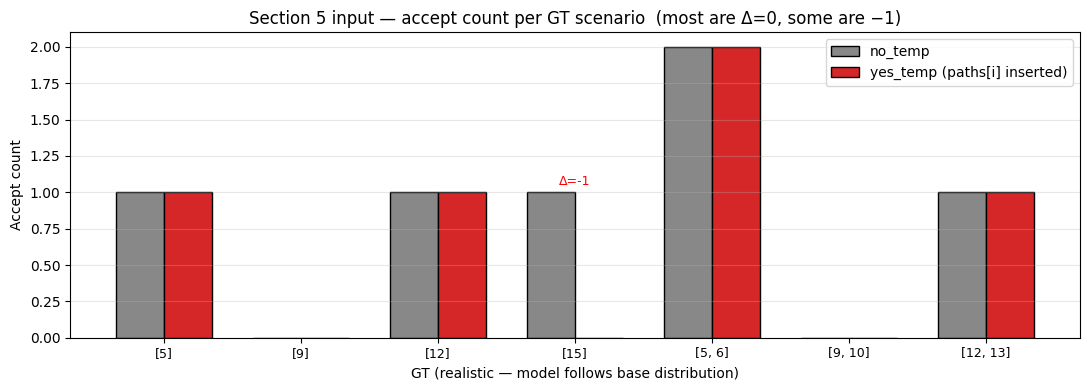

In [49]:
s = R["section_5_counter_edge"]
print(f"With-temp draft = {s['with_temp_draft'][:6]}")
print("  Note: 100 (paths[i] 의 새 토큰) 이 들어가면서 base 의 일부 후보가 밀려남.")
print()
print("Realistic GT scenarios (model 이 base 분포 따라감):")
rows = []
for r in s["realistic_GTs"]:
    sign = "+" if r["delta"] > 0 else ("−" if r["delta"] < 0 else "=")
    rows.append({
        "GT": str(r["gt"]), "no_temp_acc": r["acc_no"],
        "yes_temp_acc": r["acc_yes"], "Δaccept": f"{r['delta']:+d} ({sign})",
    })
print(pd.DataFrame(rows).to_string(index=False))

# Chart: accept counts per realistic GT scenario
fig, ax = plt.subplots(figsize=(11, 4))
labels = [str(r["gt"]) for r in s["realistic_GTs"]]
acc_no = [r["acc_no"] for r in s["realistic_GTs"]]
acc_yes = [r["acc_yes"] for r in s["realistic_GTs"]]
deltas = [r["delta"] for r in s["realistic_GTs"]]
x = np.arange(len(labels)); width = 0.35
ax.bar(x - width/2, acc_no, width, label="no_temp",
       color="#888888", edgecolor="black")
ax.bar(x + width/2, acc_yes, width, label="yes_temp (paths[i] inserted)",
       color="#d62728", edgecolor="black")
for i, (a, b, d) in enumerate(zip(acc_no, acc_yes, deltas)):
    if d != 0:
        ax.text(i, max(a, b) + 0.05, f"Δ={d:+d}",
                ha="center", fontsize=9,
                color="green" if d > 0 else "red")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_xlabel("GT (realistic — model follows base distribution)")
ax.set_ylabel("Accept count")
ax.set_title("Section 5 input — accept count per GT scenario  (most are Δ=0, some are −1)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 6. Score dilution 수치 확인 — 시뮬레이터의 negative bias 원인

`paths[i]` 가 trie 에 들어가면 path 위 internal node 들의 count 가 +1.
그러나 path-compressed segment 의 chars 가 같은 prob 으로 propagate 되니, 전체 score 가
**ratio C / (C+1) 만큼 SCALED**.

→ `extension_by_score:τ` filter 메소드들은 score 가 떨어져서 더 많은 anchor 가
reject 됨 → 직접적 MAT 감소.

Setup: decoded has 5 occurrences of '1', each followed by different token (10/20/30/40/50)

  no_temp:  child probs=[0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25]  score=2.0000
  yes_temp: child probs=[0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2]  score=1.6000

  Empirical ratio (yes_score / no_score) = 0.8000
  Predicted (parent_count / (parent_count + 1) = 5/6) = 0.8333
  Match (within 0.05): True

✓ score 가 정확히 dilution mechanism 으로 5/6 만큼 scaled.


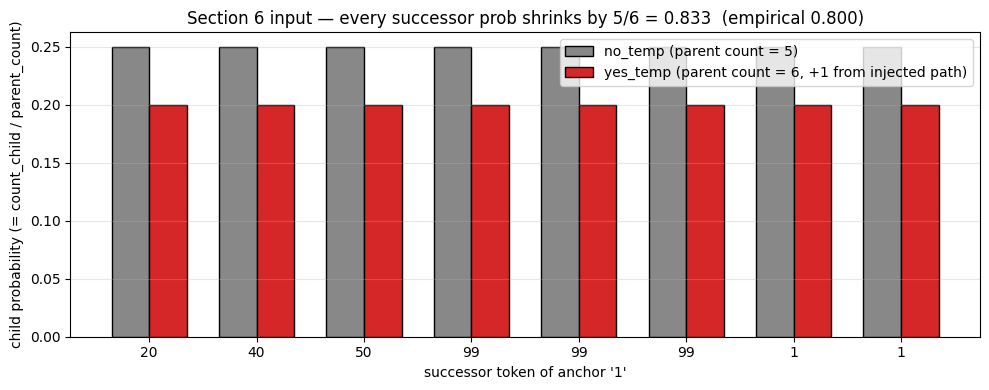

In [50]:
s = R["section_6_dilution"]
print(f"Setup: {s['setup']}")
print()
print(f"  no_temp:  child probs={[round(p, 3) for p in s['no_temp']['probs'][:8]]}  score={s['no_temp']['score']:.4f}")
print(f"  yes_temp: child probs={[round(p, 3) for p in s['yes_temp']['probs'][:8]]}  score={s['yes_temp']['score']:.4f}")
print()
print(f"  Empirical ratio (yes_score / no_score) = {s['empirical_ratio']:.4f}")
print(f"  Predicted (parent_count / (parent_count + 1) = 5/6) = {s['predicted_ratio']:.4f}")
print(f"  Match (within 0.05): {s['match']}")
print()
print("✓ score 가 정확히 dilution mechanism 으로 5/6 만큼 scaled.")

# Chart: child probability distribution before vs after dilution
fig, ax = plt.subplots(figsize=(10, 4))
n = len(s["no_temp"]["probs"])
x = np.arange(n); width = 0.35
no_probs = s["no_temp"]["probs"]
yes_probs = s["yes_temp"]["probs"]
ax.bar(x - width/2, no_probs, width, label="no_temp (parent count = 5)",
       color="#888888", edgecolor="black")
ax.bar(x + width/2, yes_probs, width,
       label="yes_temp (parent count = 6, +1 from injected path)",
       color="#d62728", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in s["no_temp"]["tokens"]])
ax.set_xlabel("successor token of anchor '1'")
ax.set_ylabel("child probability (= count_child / parent_count)")
ax.set_title(
    f"Section 6 input — every successor prob shrinks by 5/6 = "
    f"{s['predicted_ratio']:.3f}  (empirical {s['empirical_ratio']:.3f})"
)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 결론

1. **Pop bit-exact** — `extend → pop` 이 정확히 trie 를 복원 (Section 1).
2. **양쪽 트리 동기화** — `extend_active_response` 가 local + global 모두 업데이트
   (Section 2).
3. **Context manager 정상** — scope 진입에서 trie 가 변하고 종료에서 복원 (Section 3).
4. **Edge case (POSITIVE) 존재** — 합성 cyclic 데이터에서 patch 가 graft 에 도움
   되는 토큰 주입 → MAT +1 (Section 4).
5. **Counter-edge 도 존재** — 같은 setup 에서 GT 가 base 분포 따라가면 -1 (Section 5).
6. **Score dilution 수치 확인** — predicted 5/6 ratio 와 empirical 정확히 일치
   (Section 6).

**Net 효과는 워크로드의 GT 분포에 의존**:
- Cyclic GT 비중 높으면 net 양수.
- Base-distribution-following GT 비중 높으면 net 음수.
- 우리 실제 워크로드 (specbench/bfcl_v4/swebench): 후자 → 작은 음수.

→ 다음 노트북 (`pop_patch_3wl_comparison.ipynb`) 에서 실제 3 워크로드의
  patch 전후 결과 비교.